In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# create a variable to store the file path
filepath_istat_data = '../raw/dati_istat.csv'

# create df_istat_data to read the Istat data from the file path
df_istat_data = pd.read_csv(filepath_istat_data)

# load the historical comuni data from all yearly CSV files
df_comuni_list = []
for anno in range(2001, 2025):
    df = pd.read_csv(f'../raw/comuni_{anno}.csv', sep=';')
    df['Anno'] = anno
    df_comuni_list.append(df)

df_comuni = pd.concat(df_comuni_list, ignore_index=True)

In [3]:
# check for missing values in df_istat_data
df_istat_data.isnull().sum()

# delete columns with all missing values
df_istat_data.dropna(axis=1, how='all', inplace=True)

In [4]:
# check for missing values in the df_comuni
df_comuni.isnull().sum()

# keep only the columns that are needed for the analysis
df_comuni = df_comuni[['Codice Comune (numerico)', 'Comune', 'Superficie (Kmq)', 'Popolazione residente', 'Anno']]

# display the first 5 rows of the dataframe
df_comuni.head()

,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente,Anno
0,1001,Agliè,"13,1462",2557,2001
1,1002,Airasca,"15,7393",3543,2001
2,1003,Ala di Stura,"46,3315",480,2001
3,1004,Albiano d'Ivrea,"11,7315",1687,2001
4,1005,Alice Superiore,"7,3796",619,2001


In [5]:
# check the info of the dataframe
df_comuni.info()

# convert the 'Superficie (Kmq)' column to float
df_comuni['Superficie (Kmq)'] = df_comuni['Superficie (Kmq)'].str.replace('.', '', regex=False).str.replace(',', '.').astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192731 entries, 0 to 192730
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Codice Comune (numerico)  192731 non-null  int64 
 1   Comune                    192707 non-null  object
 2   Superficie (Kmq)          192731 non-null  object
 3   Popolazione residente     192731 non-null  int64 
 4   Anno                      192731 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 7.4+ MB


In [6]:
# check the info of the dataframe
df_comuni.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192731 entries, 0 to 192730
Data columns (total 5 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Codice Comune (numerico)  192731 non-null  int64  
 1   Comune                    192707 non-null  object 
 2   Superficie (Kmq)          192731 non-null  float64
 3   Popolazione residente     192731 non-null  int64  
 4   Anno                      192731 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 7.4+ MB


In [7]:
# check for missing values in the 'Comune' column
df_comuni[df_comuni['Comune'].isnull()]

# replace the missing values in the 'Comune' column with 'None'
df_comuni.loc[df_comuni['Codice Comune (numerico)'] == 1168, 'Comune'] = 'None'

# check if the missing values in the 'Comune' column have been replaced
df_comuni[df_comuni['Codice Comune (numerico)'] == 1168]

,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente,Anno
167,1168,None,24.6422,7749,2001
8269,1168,None,24.6422,7777,2002
16371,1168,None,24.6422,7822,2003
24471,1168,None,24.6422,7838,2004
32572,1168,None,24.6422,7815,2005
40673,1168,None,24.6422,7798,2006
48774,1168,None,24.6422,7866,2007
56875,1168,None,24.6422,7873,2008
64976,1168,None,24.6422,7859,2009
73076,1168,None,24.6422,7986,2010


In [8]:
# create a new dataframe df_killinj that contains the sum of the 'OBS_VALUE' column for each 'REF_AREA' and 'TIME_PERIOD' where 'DATA_TYPE' is 'KILLINJ'
df_killinj=df_istat_data[df_istat_data['DATA_TYPE']=='KILLINJ'].groupby(['REF_AREA', 'TIME_PERIOD'])['OBS_VALUE'].sum().reset_index()

# create a new dataframe df_roadacc that contains the sum of the 'OBS_VALUE' column for each 'REF_AREA' and 'TIME_PERIOD' where 'DATA_TYPE' is 'ROADACC' and 'RESULT' is '9'
df_roadacc = df_istat_data[(df_istat_data['DATA_TYPE'] == 'ROADACC') & (df_istat_data['RESULT'] == '9')].groupby(['REF_AREA', 'TIME_PERIOD'])['OBS_VALUE'].sum().reset_index()

In [9]:
# merge the two dataframes on 'REF_AREA' and 'TIME_PERIOD'
df_merged_istat_data = pd.merge(df_killinj, df_roadacc, on=['REF_AREA', 'TIME_PERIOD'])

# rename the columns for clarity
df_merged_istat_data.rename(columns={'OBS_VALUE_x': 'KILLINJ', 'OBS_VALUE_y': 'ROADACC'}, inplace=True)

# display the first 5 rows of the merged dataframe
df_merged_istat_data.head()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC
0,1001,2001,10,5
1,1001,2002,10,5
2,1001,2003,7,4
3,1001,2004,13,9
4,1001,2005,2,2


In [10]:
# merge the df_merged_istat_data with df_comuni on 'REF_AREA' and 'TIME_PERIOD' and 'Codice Comune (numerico)' to get the name of the comune
df_merged_istat_data_comuni_name=pd.merge(df_merged_istat_data, df_comuni, left_on=['REF_AREA', 'TIME_PERIOD'], right_on=['Codice Comune (numerico)', 'Anno'], how='left')

# display the first 5 rows of the merged dataframe
df_merged_istat_data_comuni_name.head()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC,Codice Comune (numerico),Comune,Superficie (Kmq),Popolazione residente,Anno
0,1001,2001,10,5,1001.0,Agliè,13.1462,2557.0,2001.0
1,1001,2002,10,5,1001.0,Agliè,13.1462,2538.0,2002.0
2,1001,2003,7,4,1001.0,Agliè,13.1462,2588.0,2003.0
3,1001,2004,13,9,1001.0,Agliè,13.1462,2679.0,2004.0
4,1001,2005,2,2,1001.0,Agliè,13.1462,2674.0,2005.0


In [11]:
# delete the 'Codice Comune (numerico)' column as it is no longer needed
df_merged_istat_data_comuni_name.drop(columns=['Codice Comune (numerico)'], inplace=True)

# display the first 5 rows of the final dataframe
df_merged_istat_data_comuni_name.head()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC,Comune,Superficie (Kmq),Popolazione residente,Anno
0,1001,2001,10,5,Agliè,13.1462,2557.0,2001.0
1,1001,2002,10,5,Agliè,13.1462,2538.0,2002.0
2,1001,2003,7,4,Agliè,13.1462,2588.0,2003.0
3,1001,2004,13,9,Agliè,13.1462,2679.0,2004.0
4,1001,2005,2,2,Agliè,13.1462,2674.0,2005.0


In [12]:
# create a new column 'ROADACC_PER_CAPITA' that contains the number of road accidents per capita for each comune
df_merged_istat_data_comuni_name['ROADACC_PER_CAPITA'] = df_merged_istat_data_comuni_name['ROADACC'] / df_merged_istat_data_comuni_name['Popolazione residente']

# create a new column 'df_roadacc_per_km2' that contains the number of road accidents per km2 for each comune
df_merged_istat_data_comuni_name['ROADACC_PER_KM2'] = df_merged_istat_data_comuni_name['ROADACC'] / df_merged_istat_data_comuni_name['Superficie (Kmq)']

# display the first 5 rows of the final dataframe
df_merged_istat_data_comuni_name.head()

,REF_AREA,TIME_PERIOD,KILLINJ,ROADACC,Comune,Superficie (Kmq),Popolazione residente,Anno,ROADACC_PER_CAPITA,ROADACC_PER_KM2
0,1001,2001,10,5,Agliè,13.1462,2557.0,2001.0,0.001955,0.380338
1,1001,2002,10,5,Agliè,13.1462,2538.0,2002.0,0.001970,0.380338
2,1001,2003,7,4,Agliè,13.1462,2588.0,2003.0,0.001546,0.304270
3,1001,2004,13,9,Agliè,13.1462,2679.0,2004.0,0.003359,0.684608
4,1001,2005,2,2,Agliè,13.1462,2674.0,2005.0,0.000748,0.152135


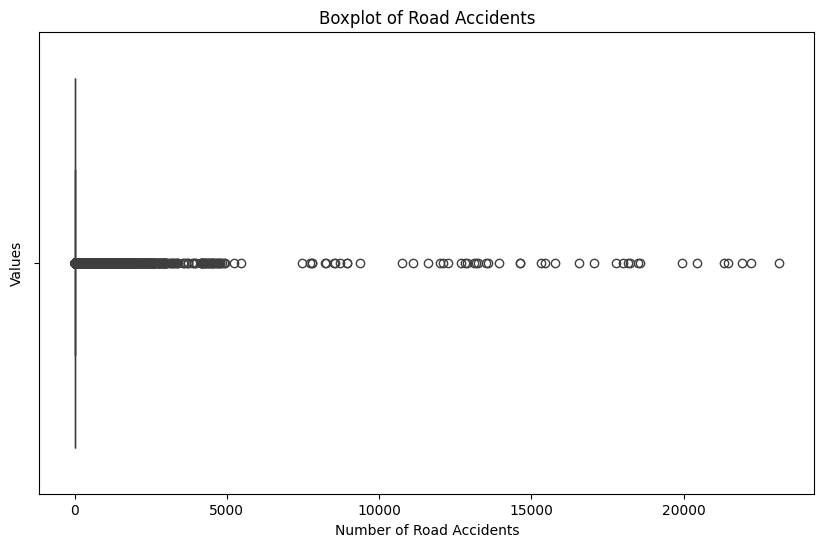

In [13]:
# check for outliers in the 'ROADACC' column using a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_merged_istat_data_comuni_name['ROADACC'])
plt.title('Boxplot of Road Accidents')
plt.xlabel('Number of Road Accidents')
plt.ylabel('Values')
plt.show()

## Outlier Analysis

The boxplot shows several municipalities with very high accident counts (up to 23,000+). 
These values are not errors but represent large, densely populated cities such as Rome, Milan, Naples and Turin.
Removing these outliers would eliminate the most relevant data points for our analysis.
Therefore, we decided to keep all values in the dataset.

In [14]:
# filter the df_merged_istat_data_comuni_name dataframe to only include rows where the 'Popolazione residente' column is not null
df_merged_istat_data_comuni_name = df_merged_istat_data_comuni_name[df_merged_istat_data_comuni_name['Popolazione residente'].notna()]

# save the cleaned dataframe to a new CSV file
df_merged_istat_data_comuni_name.to_csv('../clean/cleaned_istat_data.csv', index=False)